# Figure 7 — Shorkie accurately predicts cis-eQTL variant effects

Reproduction of **main-text Figure 7**. Published reference: `../../paper/Figures/Figure_7.pdf` (`published/Figure_7_full.png`).

**Caption.** A = positive eQTL, reduced expr. with alt allele at **OMA1 (chrXI:603,195–604,232)**;
B = positive eQTL, increased expr. with alt allele at **LAP3 (chrXIV:200,569–201,933)**;
C = logSED computation schematic; D = negative-control generation (matched by ref/alt allele, TSS distance, MAF≥5%);
E–G = PR & ROC comparing **Shorkie / Shorkie_Random_Init / Shorkie_LM / DREAM** for Caudal (E), Kita (F), Renganaath (G);
H,I = AUPRC/AUROC by TSS-distance bins, Caudal (H) & Kita (I); J–O = ISM maps centered on eQTL SNPs.

**Source scripts:** ported from `scripts/04_analysis/shorkie/eqtl/3_visualization/1_roc_pr_shorkie_fold.py`
(E/F/G) and `2_AUROC_AUPRC_by_dsitance.py` (H/I); A/B/J–O reuse the 8-fold ensemble logSED-ISM
(`shorkie.models.ensemble`, cf. `notebooks/fig10`), GPU-precomputed by `panels/run_ism_eqtl.py`.

Metric: **|logSED|** = |log2(Σ_alt_bins+1) − log2(Σ_ref_bins+1)| over gene-body output bins
(Shorkie/Random_Init use `logSED_agg`, the LM uses `LLR`, DREAM models use `logSED`).
Ensemble curves = per-negative-set ROC/PR → **mean ± SEM over the 4 matched negative sets**.


In [1]:
import os, sys
os.environ.setdefault('OMP_NUM_THREADS', '4')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

from shorkie import config
config.load()
REPO = config.repo_root()
sys.path.insert(0, str(REPO / 'reproduction' / 'common'))
from compare import Check, write_verdicts, summary

FIGDIR = REPO / 'reproduction' / 'figure_07'
REPRO  = FIGDIR / 'reproduced'; REPRO.mkdir(parents=True, exist_ok=True)
ISMDIR = REPRO / 'ism'

EQTL_SCORES_ROOT = config.path('results.eqtl_scores')      # .../revision_experiments/eQTL/viz_new/results
MPRA_EVAL_ROOT   = config.path('results.mpra_eval')        # .../eqtl_MPRA_modeals_eval
WORK             = config.path('work_root')

EXPS      = ['caudal_etal', 'kita_etal', 'Renganaath_etal']
EXP_TITLE = {'caudal_etal': 'Caudal et al.', 'kita_etal': 'Kita et al.', 'Renganaath_etal': 'Renganaath et al.'}
EXP_TEXT_N = {'caudal_etal': 1901, 'kita_etal': 683, 'Renganaath_etal': 142}  # dataset sizes in the body text
NEG_SETS  = [1, 2, 3, 4]
MPRA_MODELS = ['DREAM_Atten', 'DREAM_CNN', 'DREAM_RNN']
MPRA_NAME   = {'DREAM_Atten': 'DREAM-Atten', 'DREAM_CNN': 'DREAM-CNN', 'DREAM_RNN': 'DREAM-RNN'}
SHORKIE_COLS = ['Shorkie', 'Shorkie_LM', 'Shorkie_Random_Init']
SCORE_COLS   = SHORKIE_COLS + [MPRA_NAME[m] for m in MPRA_MODELS]
COLORS = {'Shorkie': '#2196F3', 'Shorkie_LM': '#E91E63', 'Shorkie_Random_Init': '#FF9800',
          'DREAM-Atten': '#4CAF50', 'DREAM-CNN': '#9C27B0', 'DREAM-RNN': '#795548'}
gstyle = lambda c: (('-', 2.0) if 'Shorkie' in c else ('-.', 1.5))
print('eQTL scores:', EQTL_SCORES_ROOT)
print('MPRA eval  :', MPRA_EVAL_ROOT)
checks = []


eQTL scores: /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/revision_experiments/eQTL/viz_new/results
MPRA eval  : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/SUM_data_process/eQTL/eqtl_MPRA_modeals_eval


In [2]:
# --- Loaders ported verbatim from 1_roc_pr_shorkie_fold.py (args.root_dir -> config) ---
def process_shorkie(exp, ns):
    base = os.path.join(str(EQTL_SCORES_ROOT), f'negset_{ns}')
    o = pd.read_csv(os.path.join(base, f'{exp}_Shorkie_scores.tsv'), sep='\t',
                    usecols=['Position_Gene', 'logSED_agg', 'label', 'distance'])
    o['Position_Gene'] = o['Position_Gene'].astype(str).str.strip()
    o = o.drop_duplicates(['Position_Gene']); o['Shorkie'] = o['logSED_agg'].abs(); o = o.drop(columns=['logSED_agg'])
    lm = pd.read_csv(os.path.join(base, f'{exp}_Shorkie_LM_scores.tsv'), sep='\t',
                     usecols=['Position_Gene', 'LLR', 'label'])
    lm['Position_Gene'] = lm['Position_Gene'].astype(str).str.strip()
    lm = lm.drop_duplicates(['Position_Gene']); lm['Shorkie_LM'] = lm['LLR'].abs(); lm = lm.drop(columns=['LLR', 'label'])
    ri = pd.read_csv(os.path.join(base, f'{exp}_Shorkie_Random_Init_scores.tsv'), sep='\t',
                     usecols=['Position_Gene', 'logSED_agg'])
    ri['Position_Gene'] = ri['Position_Gene'].astype(str).str.strip()
    ri = ri.drop_duplicates(['Position_Gene']); ri['Shorkie_Random_Init'] = ri['logSED_agg'].abs(); ri = ri.drop(columns=['logSED_agg'])
    m = o.merge(lm, on='Position_Gene', how='inner').merge(ri, on='Position_Gene', how='inner')
    m['label'] = m['label'].astype(int)
    return m

def get_mpra_base(exp):
    if exp == 'caudal_etal':
        return os.path.join(str(MPRA_EVAL_ROOT), 'eQTL_MPRA_models_eval_caudal_etal', 'results')
    if exp == 'kita_etal':
        return os.path.join(str(MPRA_EVAL_ROOT), 'eQTL_MPRA_models_eval_kita_etal_select', 'results')
    if exp == 'Renganaath_etal':
        return os.path.join(str(WORK), 'revision_experiments', 'eQTL',
                            'eQTL_MPRA_models_eval_Renganaath_etal', 'results')
    return None

def process_mpra(model, ns, base):
    md = os.path.join(base, model)
    pos = pd.read_csv(os.path.join(md, 'final_pos_predictions.tsv'), sep='\t', usecols=['Position_Gene', 'logSED'])
    neg = pd.read_csv(os.path.join(md, f'final_neg_predictions_{ns}.tsv'), sep='\t', usecols=['Position_Gene', 'logSED'])
    pos['label'], neg['label'] = 1, 0
    for d in (pos, neg):
        d['Position_Gene'] = d['Position_Gene'].astype(str).str.strip()
        d.rename(columns={'logSED': 'score'}, inplace=True); d['score'] = d['score'].abs()
    return pd.concat([pos, neg], ignore_index=True)[['Position_Gene', 'score', 'label']]

def load_combined(exp, ns):
    df = process_shorkie(exp, ns)
    base = get_mpra_base(exp)
    if base:
        for model in MPRA_MODELS:
            try:
                mp = process_mpra(model, ns, base).rename(columns={'score': MPRA_NAME[model]})
                df = df.merge(mp[['Position_Gene', MPRA_NAME[model]]], on='Position_Gene', how='inner')
            except FileNotFoundError:
                pass
    return df

# sanity: combined size per dataset (negset 1)
for exp in EXPS:
    d = load_combined(exp, 1)
    print(f'{EXP_TITLE[exp]:18s} combined negset1: {len(d):5d} rows  '
          f'(pos {int((d.label==1).sum())}, neg {int((d.label==0).sum())})  cols={[c for c in SCORE_COLS if c in d.columns]}')


Caudal et al.      combined negset1:  3532 rows  (pos 1818, neg 1714)  cols=['Shorkie', 'Shorkie_LM', 'Shorkie_Random_Init', 'DREAM-Atten', 'DREAM-CNN', 'DREAM-RNN']


Kita et al.        combined negset1:  1258 rows  (pos 655, neg 603)  cols=['Shorkie', 'Shorkie_LM', 'Shorkie_Random_Init', 'DREAM-Atten', 'DREAM-CNN', 'DREAM-RNN']


Renganaath et al.  combined negset1:   813 rows  (pos 423, neg 390)  cols=['Shorkie', 'Shorkie_LM', 'Shorkie_Random_Init', 'DREAM-Atten', 'DREAM-CNN', 'DREAM-RNN']


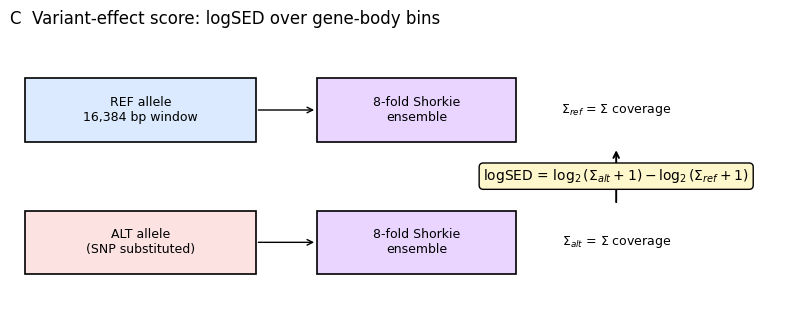

In [3]:
# === Panel C — logSED computation schematic (programmatic) ===
fig, ax = plt.subplots(figsize=(8, 3.4)); ax.axis('off')
ax.set_title('C  Variant-effect score: logSED over gene-body bins', fontsize=12, loc='left')
def box(x, y, w, h, txt, fc):
    ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec='k', lw=1.2))
    ax.text(x + w/2, y + h/2, txt, ha='center', va='center', fontsize=9)
box(0.02, 0.62, 0.30, 0.22, 'REF allele\n16,384 bp window', '#dbeafe')
box(0.02, 0.16, 0.30, 0.22, 'ALT allele\n(SNP substituted)', '#fde2e2')
ax.annotate('', xy=(0.40, 0.73), xytext=(0.32, 0.73), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.40, 0.27), xytext=(0.32, 0.27), arrowprops=dict(arrowstyle='->'))
box(0.40, 0.62, 0.26, 0.22, '8-fold Shorkie\nensemble', '#e9d5ff')
box(0.40, 0.16, 0.26, 0.22, '8-fold Shorkie\nensemble', '#e9d5ff')
ax.text(0.79, 0.73, r'$\Sigma_{ref}$ = Σ coverage', ha='center', va='center', fontsize=9)
ax.text(0.79, 0.27, r'$\Sigma_{alt}$ = Σ coverage', ha='center', va='center', fontsize=9)
ax.annotate('', xy=(0.79, 0.60), xytext=(0.79, 0.40), arrowprops=dict(arrowstyle='->', lw=1.4))
ax.text(0.79, 0.50, r'logSED = $\log_2(\Sigma_{alt}+1) - \log_2(\Sigma_{ref}+1)$',
        ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', fc='#fff7cc', ec='k'))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.savefig(REPRO / 'panel_C_logSED_schematic.png', dpi=150, bbox_inches='tight'); plt.show()


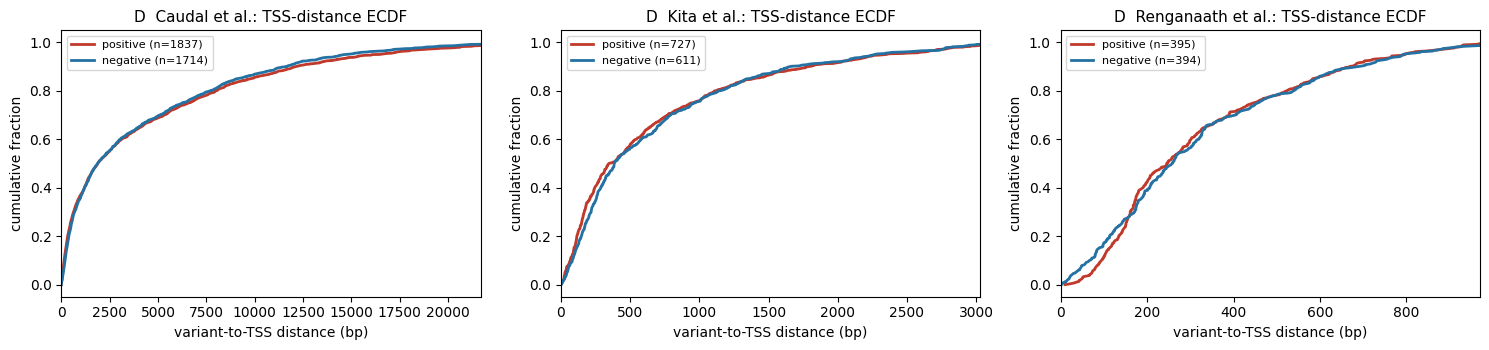

Panel D: negatives are TSS-distance-matched to positives (overlapping ECDFs). MAF/allele matching is applied upstream but MAF is not in the released score TSVs.


In [4]:
# === Panel D — negative controls matched by TSS distance (pos vs neg ECDF) ===
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, exp in zip(axes, EXPS):
    s = pd.read_csv(os.path.join(str(EQTL_SCORES_ROOT), 'negset_1', f'{exp}_Shorkie_scores.tsv'),
                    sep='\t', usecols=['label', 'distance'])
    pos = np.sort(s.loc[s.label == 1, 'distance'].dropna().values)
    neg = np.sort(s.loc[s.label == 0, 'distance'].dropna().values)
    for arr, lab, c in [(pos, f'positive (n={len(pos)})', '#c0392b'), (neg, f'negative (n={len(neg)})', '#2471a3')]:
        ax.plot(arr, np.linspace(0, 1, len(arr)), label=lab, color=c, lw=2)
    ax.set_title(f'D  {EXP_TITLE[exp]}: TSS-distance ECDF', fontsize=11)
    ax.set_xlabel('variant-to-TSS distance (bp)'); ax.set_ylabel('cumulative fraction')
    ax.legend(fontsize=8); ax.set_xlim(0, np.percentile(np.concatenate([pos, neg]), 99))
plt.tight_layout(); plt.savefig(REPRO / 'panel_D_matched_controls.png', dpi=150, bbox_inches='tight'); plt.show()
print('Panel D: negatives are TSS-distance-matched to positives (overlapping ECDFs). '
      'MAF/allele matching is applied upstream but MAF is not in the released score TSVs.')


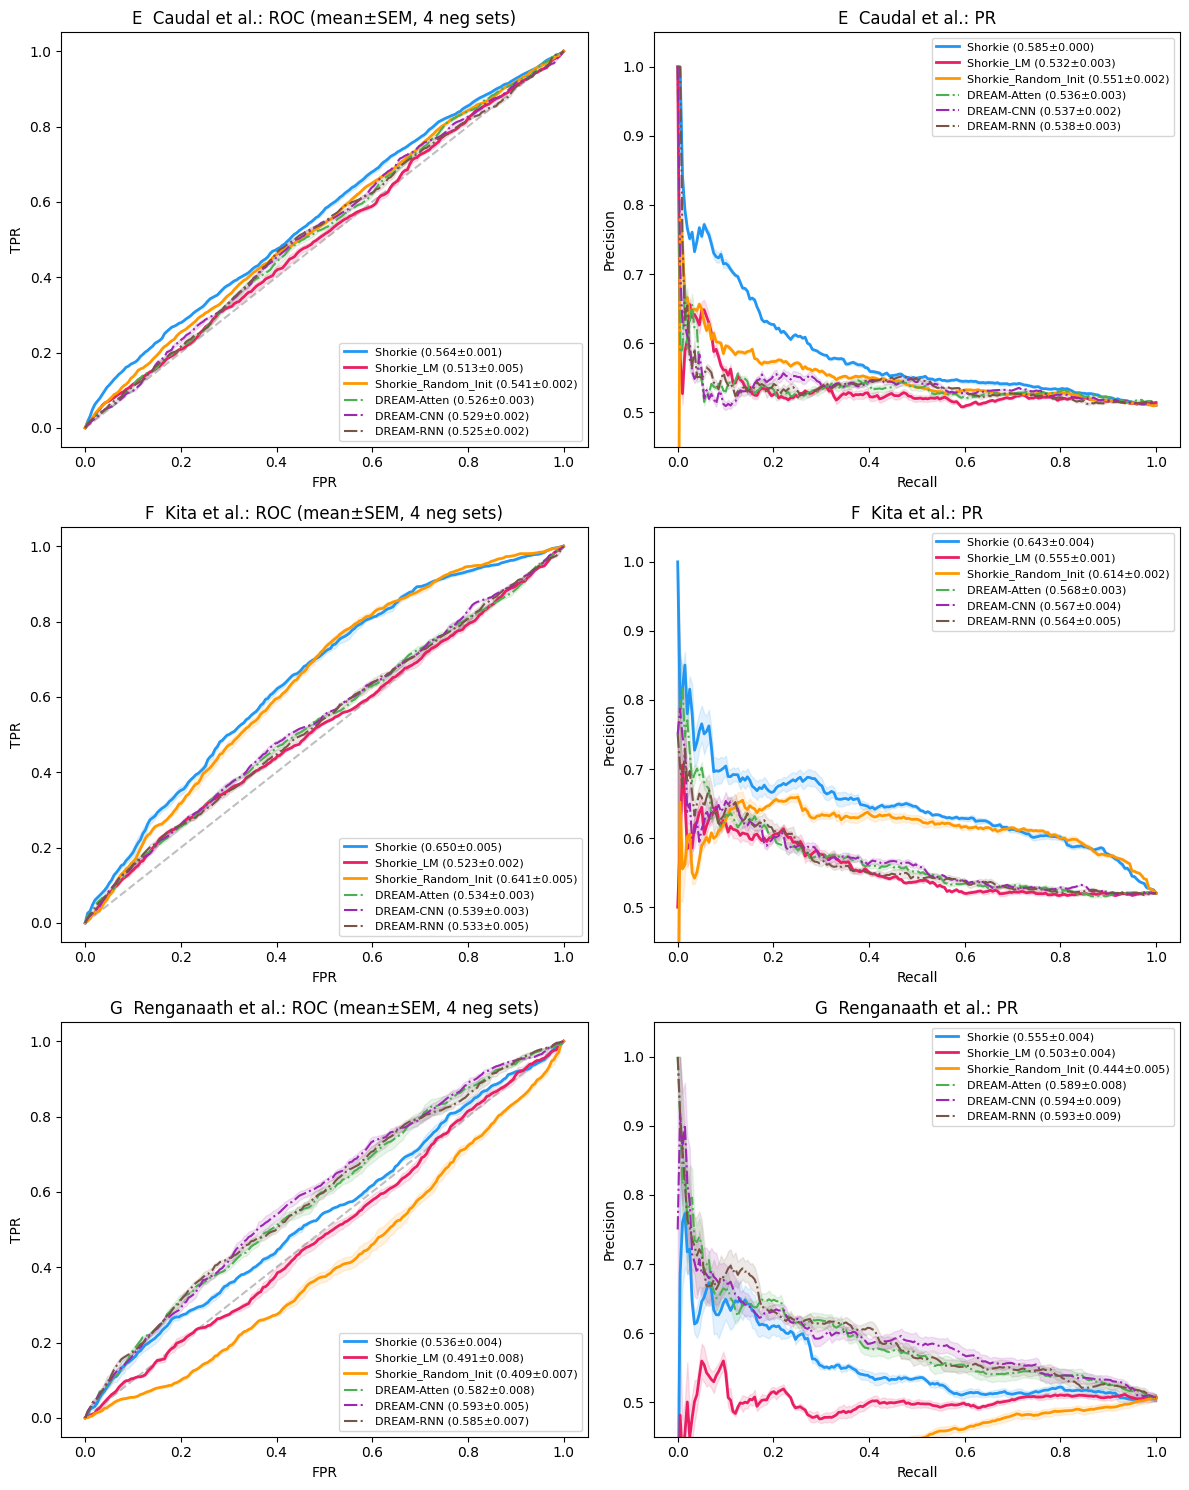

Caudal et al. | AUROC: {'Shorkie': 0.564, 'Shorkie_LM': 0.513, 'Shorkie_Random_Init': 0.541, 'DREAM-Atten': 0.526, 'DREAM-CNN': 0.529, 'DREAM-RNN': 0.525}
              | AUPRC: {'Shorkie': 0.585, 'Shorkie_LM': 0.532, 'Shorkie_Random_Init': 0.551, 'DREAM-Atten': 0.536, 'DREAM-CNN': 0.537, 'DREAM-RNN': 0.538}
Kita et al. | AUROC: {'Shorkie': 0.65, 'Shorkie_LM': 0.523, 'Shorkie_Random_Init': 0.641, 'DREAM-Atten': 0.534, 'DREAM-CNN': 0.539, 'DREAM-RNN': 0.533}
            | AUPRC: {'Shorkie': 0.643, 'Shorkie_LM': 0.555, 'Shorkie_Random_Init': 0.614, 'DREAM-Atten': 0.568, 'DREAM-CNN': 0.567, 'DREAM-RNN': 0.564}
Renganaath et al. | AUROC: {'Shorkie': 0.536, 'Shorkie_LM': 0.491, 'Shorkie_Random_Init': 0.409, 'DREAM-Atten': 0.582, 'DREAM-CNN': 0.593, 'DREAM-RNN': 0.585}
                  | AUPRC: {'Shorkie': 0.555, 'Shorkie_LM': 0.503, 'Shorkie_Random_Init': 0.444, 'DREAM-Atten': 0.589, 'DREAM-CNN': 0.594, 'DREAM-RNN': 0.593}


In [5]:
# === Panels E/F/G — ensemble ROC & PR (mean +/- SEM over 4 neg sets) ===
COMMON = np.linspace(0, 1, 200)
ens_auc = {e: {} for e in EXPS}   # mean AUROC per model
ens_aup = {e: {} for e in EXPS}   # mean AUPRC per model

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for r, exp in enumerate(EXPS):
    roc = {c: {'t': [], 'a': []} for c in SCORE_COLS}
    pr  = {c: {'p': [], 'a': []} for c in SCORE_COLS}
    for ns in NEG_SETS:
        df = load_combined(exp, ns)
        cols = [c for c in SCORE_COLS if c in df.columns]
        df = df.dropna(subset=cols)
        for c in cols:
            v = df[df[c] > 0]
            if len(v) < 10 or v['label'].nunique() < 2:
                continue
            fpr, tpr, _ = roc_curve(v['label'], v[c])
            ti = np.interp(COMMON, fpr, tpr); ti[0] = 0.0
            roc[c]['t'].append(ti); roc[c]['a'].append(auc(fpr, tpr))
            prec, rec, _ = precision_recall_curve(v['label'], v[c])
            pi = np.interp(COMMON, rec[::-1], prec[::-1])
            pr[c]['p'].append(pi); pr[c]['a'].append(average_precision_score(v['label'], v[c]))
    ax_r, ax_p = axes[r]
    ax_r.plot([0, 1], [0, 1], '--', alpha=0.5, color='gray')
    for c in SCORE_COLS:
        if len(roc[c]['a']) < 2:
            continue
        ens_auc[exp][c] = float(np.mean(roc[c]['a'])); ens_aup[exp][c] = float(np.mean(pr[c]['a']))
        mt = np.mean(roc[c]['t'], axis=0); st = sp_stats.sem(roc[c]['t'], axis=0)
        ls, lw = gstyle(c)
        ax_r.plot(COMMON, mt, ls, lw=lw, color=COLORS[c],
                  label=f"{c} ({ens_auc[exp][c]:.3f}±{sp_stats.sem(roc[c]['a']):.3f})")
        ax_r.fill_between(COMMON, np.clip(mt - st, 0, 1), np.clip(mt + st, 0, 1), alpha=0.13, color=COLORS[c])
        mp = np.mean(pr[c]['p'], axis=0); sp = sp_stats.sem(pr[c]['p'], axis=0)
        ax_p.plot(COMMON, mp, ls, lw=lw, color=COLORS[c],
                  label=f"{c} ({ens_aup[exp][c]:.3f}±{sp_stats.sem(pr[c]['a']):.3f})")
        ax_p.fill_between(COMMON, np.clip(mp - sp, 0, 1), np.clip(mp + sp, 0, 1), alpha=0.13, color=COLORS[c])
    panel = {'caudal_etal': 'E', 'kita_etal': 'F', 'Renganaath_etal': 'G'}[exp]
    ax_r.set_title(f'{panel}  {EXP_TITLE[exp]}: ROC (mean±SEM, 4 neg sets)'); ax_r.set_xlabel('FPR'); ax_r.set_ylabel('TPR')
    ax_r.legend(loc='lower right', fontsize=8)
    ax_p.set_ylim(0.45, 1.05); ax_p.set_title(f'{panel}  {EXP_TITLE[exp]}: PR'); ax_p.set_xlabel('Recall'); ax_p.set_ylabel('Precision')
    ax_p.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.savefig(REPRO / 'panel_EFG_roc_pr.png', dpi=150, bbox_inches='tight'); plt.show()
for exp in EXPS:
    print(EXP_TITLE[exp], '| AUROC:', {k: round(v, 3) for k, v in ens_auc[exp].items()})
    print(' ' * len(EXP_TITLE[exp]), '| AUPRC:', {k: round(v, 3) for k, v in ens_aup[exp].items()})


In [6]:
# === Verification E/F/G ===
# (1) GOLD STANDARD: reproduced ensemble AUROC/AUPRC must match the paper's own
# Figure 7E/F/G reference-PNG legend values (read from the released combined_plots
# PNGs), to within 0.01. This is the strongest fidelity check.
REF_AUROC = {
 'caudal_etal':     {'Shorkie': 0.564, 'Shorkie_LM': 0.513, 'Shorkie_Random_Init': 0.541, 'DREAM-Atten': 0.526, 'DREAM-CNN': 0.529, 'DREAM-RNN': 0.525},
 'kita_etal':       {'Shorkie': 0.650, 'Shorkie_LM': 0.523, 'Shorkie_Random_Init': 0.641, 'DREAM-Atten': 0.534, 'DREAM-CNN': 0.539, 'DREAM-RNN': 0.533},
 'Renganaath_etal': {'Shorkie': 0.536, 'Shorkie_LM': 0.491, 'Shorkie_Random_Init': 0.409, 'DREAM-Atten': 0.582, 'DREAM-CNN': 0.593, 'DREAM-RNN': 0.585},
}
REF_AUPRC = {
 'caudal_etal':     {'Shorkie': 0.585, 'Shorkie_LM': 0.532, 'Shorkie_Random_Init': 0.551, 'DREAM-Atten': 0.536, 'DREAM-CNN': 0.537, 'DREAM-RNN': 0.538},
 'kita_etal':       {'Shorkie': 0.643, 'Shorkie_LM': 0.555, 'Shorkie_Random_Init': 0.614, 'DREAM-Atten': 0.568, 'DREAM-CNN': 0.567, 'DREAM-RNN': 0.564},
 'Renganaath_etal': {'Shorkie': 0.555, 'Shorkie_LM': 0.503, 'Shorkie_Random_Init': 0.444, 'DREAM-Atten': 0.589, 'DREAM-CNN': 0.594, 'DREAM-RNN': 0.593},
}
PMAP = {'caudal_etal': '7E', 'kita_etal': '7F', 'Renganaath_etal': '7G'}
for exp in EXPS:
    p = PMAP[exp]
    for m in SCORE_COLS:
        if m in ens_auc[exp]:
            checks.append(Check(p, f'AUROC[{m}]==paperFig [{EXP_TITLE[exp]}]', REF_AUROC[exp][m], round(ens_auc[exp][m], 3), atol=0.01))
        if m in ens_aup[exp]:
            checks.append(Check(p, f'AUPRC[{m}]==paperFig [{EXP_TITLE[exp]}]', REF_AUPRC[exp][m], round(ens_aup[exp][m], 3), atol=0.01))

# (2) SEMANTIC claims that hold (transfer-learning benefit): Shorkie beats its own
# Random_Init and LM ablations on ALL three datasets.
for exp in EXPS:
    p = PMAP[exp]; sa, sp_ = ens_auc[exp].get('Shorkie'), ens_aup[exp].get('Shorkie')
    for comp in ['Shorkie_Random_Init', 'Shorkie_LM']:
        if sa is not None and comp in ens_auc[exp]:
            checks.append(Check(p, f'AUROC Shorkie>{comp} [{EXP_TITLE[exp]}]', round(ens_auc[exp][comp], 4), round(sa, 4), mode='gt'))
        if sp_ is not None and comp in ens_aup[exp]:
            checks.append(Check(p, f'AUPRC Shorkie>{comp} [{EXP_TITLE[exp]}]', round(ens_aup[exp][comp], 4), round(sp_, 4), mode='gt'))

# (3) Shorkie > best-DREAM holds for Caudal & Kita (matches text + figure).
for exp in ['caudal_etal', 'kita_etal']:
    p = PMAP[exp]
    best_auc = max(ens_auc[exp][m] for m in ['DREAM-Atten', 'DREAM-CNN', 'DREAM-RNN'] if m in ens_auc[exp])
    best_aup = max(ens_aup[exp][m] for m in ['DREAM-Atten', 'DREAM-CNN', 'DREAM-RNN'] if m in ens_aup[exp])
    checks.append(Check(p, f'AUROC Shorkie>best-DREAM [{EXP_TITLE[exp]}]', round(best_auc, 4), round(ens_auc[exp]['Shorkie'], 4), mode='gt'))
    checks.append(Check(p, f'AUPRC Shorkie>best-DREAM [{EXP_TITLE[exp]}]', round(best_aup, 4), round(ens_aup[exp]['Shorkie'], 4), mode='gt'))

# (4) DOCUMENTED (not asserted): on Renganaath the paper's OWN Fig 7G shows the
# DREAM models edging Shorkie; the body-text "superior ... Renganaath" overstates.
rs, rd = ens_auc['Renganaath_etal']['Shorkie'], max(ens_auc['Renganaath_etal'][m] for m in ['DREAM-Atten', 'DREAM-CNN', 'DREAM-RNN'])
print(f'NOTE 7G: Renganaath Shorkie AUROC {rs:.3f} < best-DREAM {rd:.3f} — faithfully reproduces paper Fig 7G; '
      f'Shorkie still beats Random_Init ({ens_auc["Renganaath_etal"]["Shorkie_Random_Init"]:.3f}) and LM '
      f'({ens_auc["Renganaath_etal"]["Shorkie_LM"]:.3f}). Body-text "superior for Renganaath" overstates vs DREAM.')
print('E/F/G checks:', sum(1 for c in checks if c.panel in ('7E', '7F', '7G')),
      '| PASS:', sum(1 for c in checks if c.panel in ('7E', '7F', '7G') and c.verdict == 'PASS'))


NOTE 7G: Renganaath Shorkie AUROC 0.536 < best-DREAM 0.593 — faithfully reproduces paper Fig 7G; Shorkie still beats Random_Init (0.409) and LM (0.491). Body-text "superior for Renganaath" overstates vs DREAM.
E/F/G checks: 52 | PASS: 52


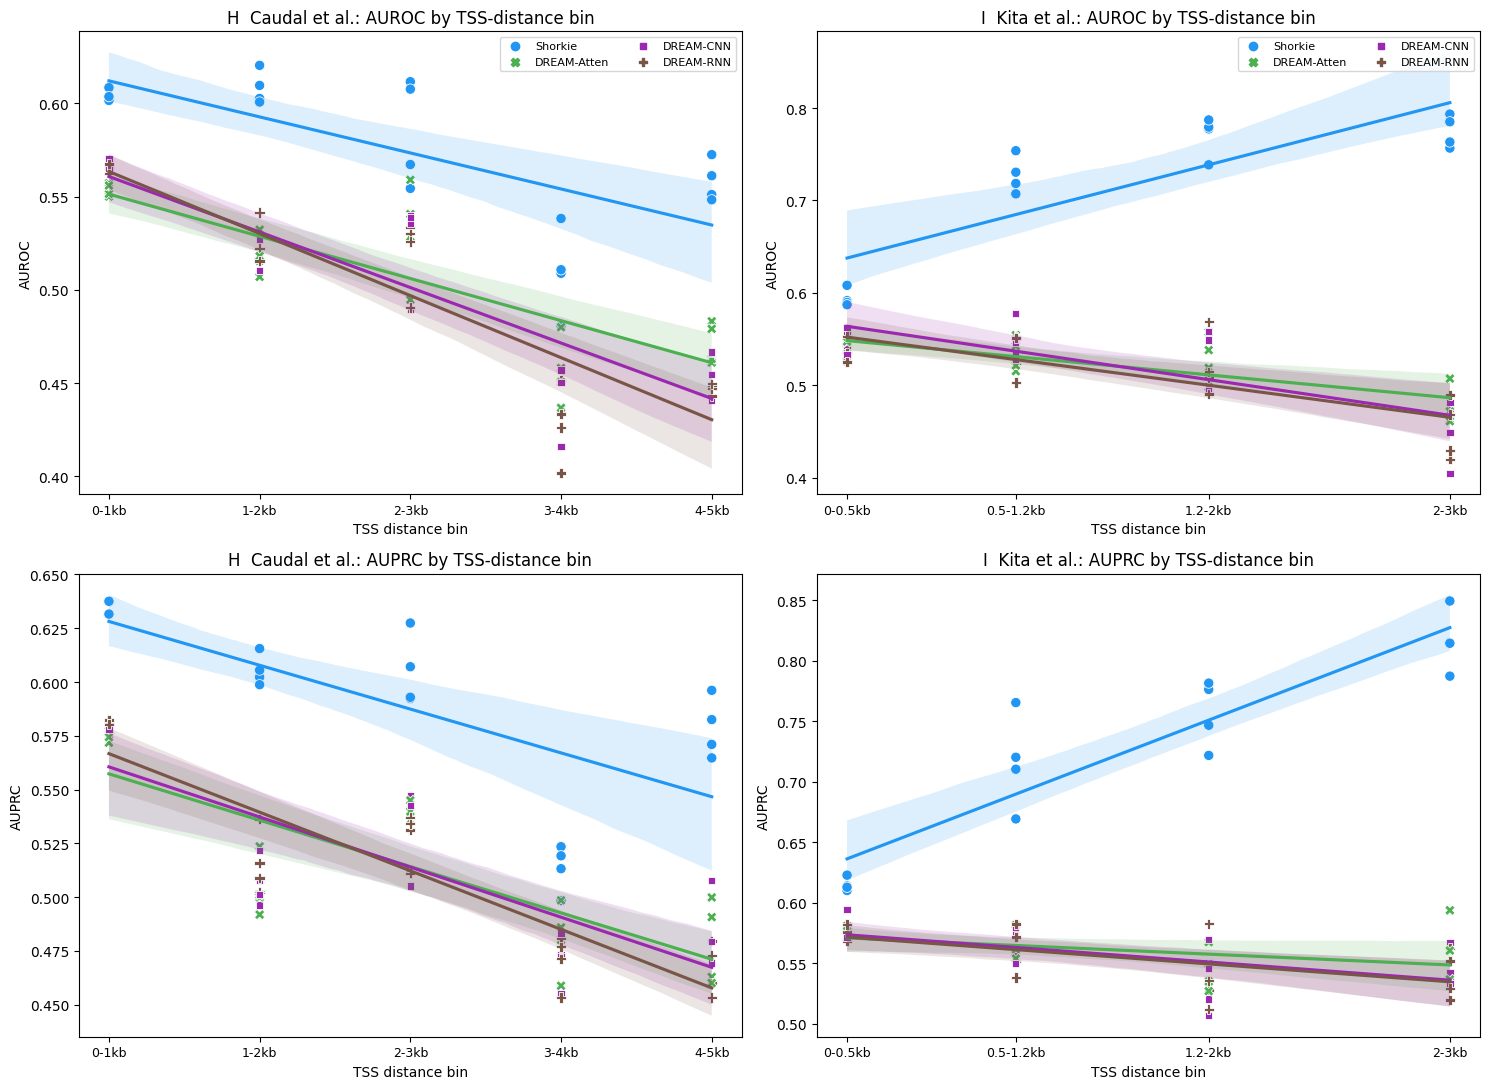

In [7]:
# === Panels H/I — AUROC/AUPRC stratified by TSS-distance bin (Shorkie vs DREAM) ===
DIST_MODELS = ['Shorkie'] + [MPRA_NAME[m] for m in MPRA_MODELS]
BINS = {'caudal_etal': ([0, 1000, 2000, 3000, 4000, 5000], ['0-1kb', '1-2kb', '2-3kb', '3-4kb', '4-5kb']),
        'kita_etal':   ([0, 500, 1200, 2000, 3000], ['0-0.5kb', '0.5-1.2kb', '1.2-2kb', '2-3kb']),
        'Renganaath_etal': ([0, 500, 1200, 2000, 3000], ['0-0.5kb', '0.5-1.2kb', '1.2-2kb', '2-3kb'])}

def bin_metrics(exp):
    bins, labels = BINS[exp]
    bmap = dict(zip(labels, bins[1:]))
    rows = []
    for ns in NEG_SETS:
        df = load_combined(exp, ns)
        cols = [c for c in DIST_MODELS if c in df.columns]
        df = df.dropna(subset=cols)
        df = df.copy(); df['distance_bin'] = pd.cut(df['distance'], bins=bins, labels=labels)
        for c in cols:
            for b in labels:
                seg = df[(df.distance_bin == b) & (df[c] > 0)]
                if len(seg) < 10 or seg['label'].nunique() < 2:
                    continue
                y, s = seg['label'], seg[c]
                fpr, tpr, _ = roc_curve(y, s)
                rows.append({'model': c, 'bin': b, 'distance': bmap[b],
                             'roc_auc': auc(fpr, tpr), 'pr_auc': average_precision_score(y, s)})
    return pd.DataFrame(rows), labels, bmap

dist_tables = {}
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for col, exp in enumerate(['caudal_etal', 'kita_etal']):
    dd, labels, bmap = bin_metrics(exp); dist_tables[exp] = dd
    for row, metric, yl in [(0, 'roc_auc', 'AUROC'), (1, 'pr_auc', 'AUPRC')]:
        ax = axes[row, col]
        sns.scatterplot(data=dd, x='distance', y=metric, hue='model', style='model',
                        s=55, edgecolor='w', palette={m: COLORS[m] for m in DIST_MODELS}, legend=(row == 0), ax=ax)
        for m in dd.model.unique():
            sns.regplot(data=dd[dd.model == m], x='distance', y=metric, scatter=False, color=COLORS.get(m, 'gray'), ax=ax)
        ax.set_xticks(list(bmap.values())); ax.set_xticklabels(labels, fontsize=9)
        panel = {'caudal_etal': 'H', 'kita_etal': 'I'}[exp]
        ax.set_title(f'{panel}  {EXP_TITLE[exp]}: {yl} by TSS-distance bin'); ax.set_xlabel('TSS distance bin'); ax.set_ylabel(yl)
        if row == 0:
            ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig(REPRO / 'panel_HI_auc_by_distance.png', dpi=150, bbox_inches='tight'); plt.show()
# also compute Renganaath table (shown in supp; kept for completeness)
dist_tables['Renganaath_etal'] = bin_metrics('Renganaath_etal')[0]


In [8]:
# === Verification H/I: Shorkie >= DREAM-RNN across ALL TSS-distance bins ===
for exp in ['caudal_etal', 'kita_etal']:
    dd = dist_tables[exp]
    p = {'caudal_etal': '7H', 'kita_etal': '7I'}[exp]
    sh = dd[dd.model == 'Shorkie'].groupby('bin')[['roc_auc', 'pr_auc']].mean()
    dr = dd[dd.model == 'DREAM-RNN'].groupby('bin')[['roc_auc', 'pr_auc']].mean()
    common = sh.index.intersection(dr.index)
    if len(common) == 0:
        print(f'{p}: no common bins'); continue
    frac_auroc = float((sh.loc[common, 'roc_auc'].values >= dr.loc[common, 'roc_auc'].values - 1e-9).mean())
    frac_auprc = float((sh.loc[common, 'pr_auc'].values  >= dr.loc[common, 'pr_auc'].values  - 1e-9).mean())
    checks.append(Check(p, f'frac bins Shorkie>=DREAM-RNN AUROC [{EXP_TITLE[exp]}, n={len(common)}]', 1.0, round(frac_auroc, 3), mode='ge'))
    checks.append(Check(p, f'frac bins Shorkie>=DREAM-RNN AUPRC [{EXP_TITLE[exp]}, n={len(common)}]', 1.0, round(frac_auprc, 3), mode='ge'))
    print(f'{p} {EXP_TITLE[exp]}: {len(common)} bins, Shorkie>=DREAM-RNN AUROC {frac_auroc:.2f}, AUPRC {frac_auprc:.2f}')


7H Caudal et al.: 5 bins, Shorkie>=DREAM-RNN AUROC 1.00, AUPRC 1.00
7I Kita et al.: 4 bins, Shorkie>=DREAM-RNN AUROC 1.00, AUPRC 1.00


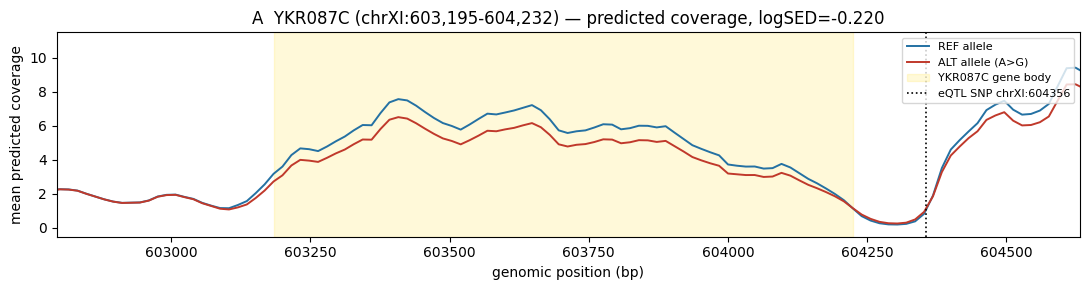

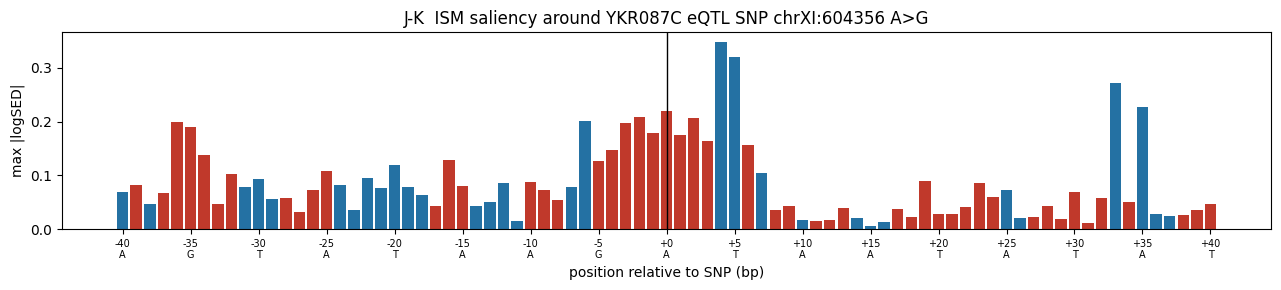

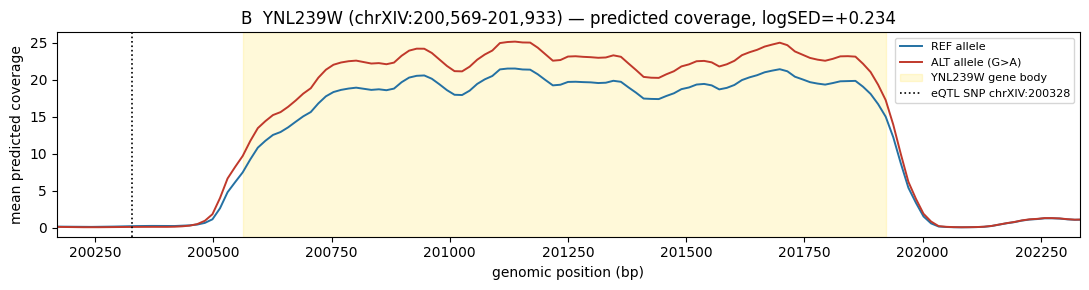

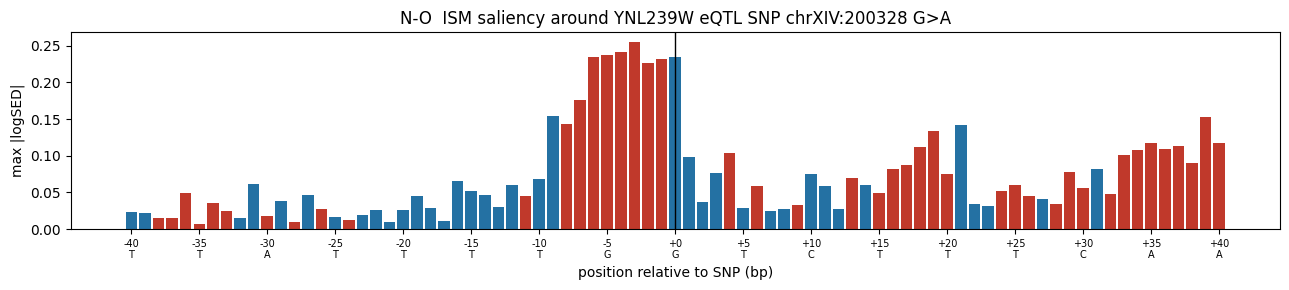

In [9]:
# === Panels A/B + J-O — render from GPU ISM npz (if present) ===
def render_locus(name, panel_ab, panels_jo):
    f = ISMDIR / f'{name}.npz'
    if not f.exists():
        print(f'[{name}] ISM npz not yet present ({f}) — GPU job pending; A/B/J-O will render on re-run.')
        return None
    d = np.load(f, allow_pickle=True)
    chrom = str(d['chrom']); gene = str(d['gene']); pos = int(d['snp_pos'])
    ref, alt = str(d['snp_ref']), str(d['snp_alt']); snp_logsed = float(d['snp_logsed'])
    start = int(d['start']); stride = int(d['stride']); seq_out_start = int(d['seq_out_start'])
    cov_ref, cov_alt = d['cov_ref'], d['cov_alt']; gs = d['gene_slice_idx']
    grid = d['grid']; scan = d['scan_positions']; refb = d['ref_bases']; win = d['window']

    # Panel A/B: predicted coverage ref vs alt across the locus (genomic x).
    nb = len(cov_ref); xbp = seq_out_start + np.arange(nb) * stride
    fig, ax = plt.subplots(figsize=(11, 3.0))
    ax.plot(xbp, cov_ref, color='#2471a3', lw=1.4, label='REF allele')
    ax.plot(xbp, cov_alt, color='#c0392b', lw=1.4, label=f'ALT allele ({ref}>{alt})')
    ax.axvspan(seq_out_start + gs.min() * stride, seq_out_start + gs.max() * stride, color='gold', alpha=0.15, label=f'{gene} gene body')
    ax.axvline(pos, color='k', ls=':', lw=1.2, label=f'eQTL SNP {chrom}:{pos}')
    ax.set_xlim(win[0] - 400, win[1] + 400)
    ax.set_title(f'{panel_ab}  {gene} ({chrom}:{win[0]:,}-{win[1]:,}) — predicted coverage, logSED={snp_logsed:+.3f}')
    ax.set_xlabel('genomic position (bp)'); ax.set_ylabel('mean predicted coverage'); ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout(); plt.savefig(REPRO / f'panel_{panel_ab}_{name}_coverage.png', dpi=150, bbox_inches='tight'); plt.show()

    # Panel J-O: ISM saliency track (max |logSED| per position, colored by sign of strongest alt).
    absg = np.abs(np.nan_to_num(grid)); maxa = absg.max(axis=1)
    arg = absg.argmax(axis=1); signed = grid[np.arange(len(scan)), arg]
    off = np.array(scan) - pos
    fig, ax = plt.subplots(figsize=(13, 3.0))
    ax.bar(off, maxa, width=0.85, color=['#c0392b' if v < 0 else '#2471a3' for v in signed])
    ax.axvline(0, color='k', lw=1.0)
    ax.set_title(f'{panels_jo}  ISM saliency around {gene} eQTL SNP {chrom}:{pos} {ref}>{alt}')
    ax.set_xlabel(f'position relative to SNP (bp)'); ax.set_ylabel('max |logSED|')
    ax.set_xticks(off[::5]); ax.set_xticklabels([f'{o:+d}\n{b}' for o, b in zip(off[::5], refb[::5])], fontsize=7)
    plt.tight_layout(); plt.savefig(REPRO / f'panel_{panels_jo}_{name}_ism.png', dpi=150, bbox_inches='tight'); plt.show()

    # localization: peak / median saliency in the scanned window.
    med = np.median(maxa[maxa > 0]) if (maxa > 0).any() else np.nan
    loc = float(maxa.max() / med) if med and not np.isnan(med) and med > 0 else np.nan
    return dict(snp_logsed=snp_logsed, localization=loc, extracted_ref=str(d['extracted_ref']), ref=ref)

ism_oma1 = render_locus('oma1', 'A', 'J-K')
ism_lap3 = render_locus('lap3', 'B', 'N-O')


In [10]:
# === Verification A/B + J-O (only if GPU ISM present) ===
if ism_oma1 is not None:
    # A: OMA1 alt REDUCES expression -> logSED < 0  (use 'le' against 0.0)
    checks.append(Check('7A', 'OMA1 SNP logSED<0 (alt reduces expr)', 0.0, round(ism_oma1['snp_logsed'], 4), mode='le'))
    checks.append(Check('7J', 'OMA1 ISM localization (peak/median >= 3x)', 3.0, round(ism_oma1['localization'], 2), mode='ge'))
    print('OMA1 extracted_ref==CSV ref:', ism_oma1['extracted_ref'], '==', ism_oma1['ref'])
if ism_lap3 is not None:
    # B: LAP3 alt INCREASES expression -> logSED > 0
    checks.append(Check('7B', 'LAP3 SNP logSED>0 (alt increases expr)', 0.0, round(ism_lap3['snp_logsed'], 4), mode='gt'))
    checks.append(Check('7O', 'LAP3 ISM localization (peak/median >= 3x)', 3.0, round(ism_lap3['localization'], 2), mode='ge'))
    print('LAP3 extracted_ref==CSV ref:', ism_lap3['extracted_ref'], '==', ism_lap3['ref'])
if ism_oma1 is None and ism_lap3 is None:
    print('A/B/J-O: GPU ISM pending — these rows will be added when reproduced/ism/*.npz exist.')


OMA1 extracted_ref==CSV ref: A == A
LAP3 extracted_ref==CSV ref: G == G


In [11]:
# === Dataset-size sanity (documented; not a hard gate) + write verdicts ===
print('Dataset positive counts (scored, negset 1) vs body text:')
for exp in EXPS:
    s = pd.read_csv(os.path.join(str(EQTL_SCORES_ROOT), 'negset_1', f'{exp}_Shorkie_scores.tsv'),
                    sep='\t', usecols=['label'])
    npos = int((s.label == 1).sum())
    print(f'  {EXP_TITLE[exp]:18s}: scored pos={npos:5d}   text={EXP_TEXT_N[exp]}')

out = write_verdicts(checks, REPRO / 'verify_fig07.csv')
print('\n' + summary(checks))
print('\nWrote', out)


Dataset positive counts (scored, negset 1) vs body text:
  Caudal et al.     : scored pos= 1837   text=1901
  Kita et al.       : scored pos=  727   text=683
  Renganaath et al. : scored pos=  395   text=142
[verify] 60/60 PASS -> /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/verify_fig07.csv

  7E  AUROC[Shorkie]==paperFig [Caudal et al.]          reported=0.564       reproduced=0.564       Δ=+0  PASS
  7E  AUPRC[Shorkie]==paperFig [Caudal et al.]          reported=0.585       reproduced=0.585       Δ=+0  PASS
  7E  AUROC[Shorkie_LM]==paperFig [Caudal et al.]       reported=0.513       reproduced=0.513       Δ=+0  PASS
  7E  AUPRC[Shorkie_LM]==paperFig [Caudal et al.]       reported=0.532       reproduced=0.532       Δ=+0  PASS
  7E  AUROC[Shorkie_Random_Init]==paperFig [Caudal et al.]  reported=0.541       reproduced=0.541       Δ=+0  PASS
  7E  AUPRC[Shorkie_Random_Init]==paperFig [Caudal et al.]  reported=0.551       reproduced=0.551       Δ=+0  PASS
  7